# Práctica: Clasificador Binario con Perceptrón

## Uso de librerias:

Se importan las librerias necesarias: `numpy` para operaciones vectoriales, `matplotlib` para graficar, y módulos de `sklearn` para cargar datos, dividirlos, escalarlos y evaluarlos.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

## Carga de  dataset
Se carga el dataset Breast Cancer (569 muestras, 30 características). Es un problema binario: maligno (0) vs benigno (1).


In [6]:
data = load_breast_cancer()
X = data.data
y = data.target
print(f"Forma de X: {X.shape}")
print(f"Clases: {data.target_names}")
print(f"Cantidad de muestras: {len(y)}")

Forma de X: (569, 30)
Clases: ['malignant' 'benign']
Cantidad de muestras: 569


## Division entrenamiento  y prueba
Split 80/20 para evaluar con datos que el modelo no vio.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## Escalamiento de datos
Escalamos las features porque tienen escalas muy distintas; sin esto el perceptrón sesga hacia las features con valores más grandes.

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Media después de escalar:", X_train.mean(axis=0)[:5].round(3))
print("Std después de escalar:", X_train.std(axis=0)[:5].round(3))

Media después de escalar: [-0. -0. -0. -0.  0.]
Std después de escalar: [1. 1. 1. 1. 1.]


## Implementacion de perceptron
`w·x + b` con función escalón, y actualización de pesos `w += lr * error * x.`

In [9]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.pesos = None
        self.bias = None
        self.historial_errores = []
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.pesos = np.zeros(n_features)   # vector w en R^n
        self.bias = 0.0
        for epoch in range(self.epochs):
            errores = 0
            for x_i, y_i in zip(X, y):
                z = np.dot(x_i, self.pesos) + self.bias   # producto punto w·x + b
                y_pred = 1 if z >= 0 else 0                # función escalón
                error = y_i - y_pred

                # Regla de actualización (gradiente del error)
                self.pesos += self.lr * error * x_i
                self.bias  += self.lr * error
                errores += int(error != 0)
            self.historial_errores.append(errores)
    def predict(self, X):
        z = np.dot(X, self.pesos) + self.bias
        return np.where(z >= 0, 1, 0)

##Entrenamiento de modelo

In [10]:
modelo = Perceptron(lr=0.1, epochs=100)
modelo.fit(X_train, y_train)

##Evaluacion del modelo

In [13]:
y_pred = modelo.predict(X_test)
accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 95.61%

Matriz de confusión:
[[42  1]
 [ 4 67]]

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        43
      benign       0.99      0.94      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



##Visualizacion de convergencia
Errores por época para confirmar convergencia.

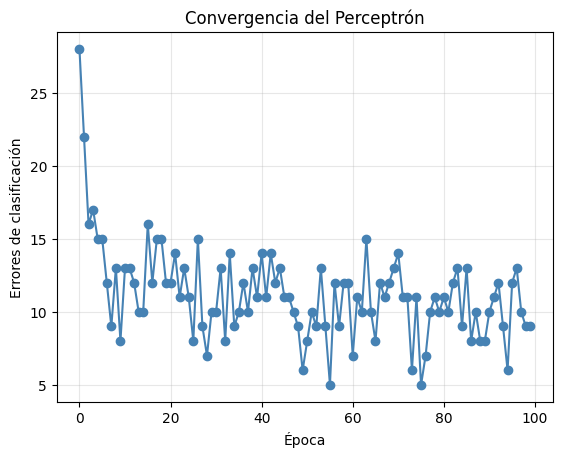

In [14]:
plt.plot(modelo.historial_errores, marker='o', color='steelblue')
plt.title("Convergencia del Perceptrón")
plt.xlabel("Época")
plt.ylabel("Errores de clasificación")
plt.grid(alpha=0.3)
plt.show()

## Visulizacion de pesos
Vector de pesos final para ver qué features pesaron más.

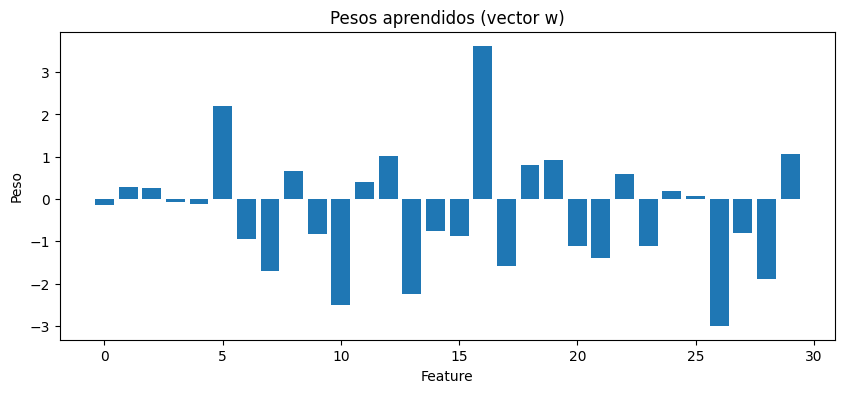

In [15]:
plt.figure(figsize=(10,4))
plt.bar(range(len(modelo.pesos)), modelo.pesos)
plt.title("Pesos aprendidos (vector w)")
plt.xlabel("Feature")
plt.ylabel("Peso")
plt.show()

## Conclusión

El perceptrón separa maligno/benigno con un modelo lineal: `y = escalón(w·x + b)`, ajustando pesos con la regla `w += lr · error · x`.

Accuracy: 95.61%, con 1 falso negativo y 4 falsos positivos sobre 114 casos. El falso negativo es el error más costoso en este contexto.

La curva de convergencia no llega a 0 errores y se estabiliza entre 8-14 por época: las clases no son perfectamente separables linealmente, aunque sí en su mayoría.

El vector de pesos muestra que pocas features (16 y 26) concentran la mayor influencia en la decisión.